### Environment Setup and MongoDB connection
Importing necessary libraries, initializing MongoDB connection and defining the database.

In [ ]:
# Import necessary libraries

# Standard
import time
import gc

# Data Processing and Database
import pandas as pd
from pymongo import MongoClient
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, avg, round, lit, when, to_timestamp, hour, unix_timestamp, lag
from functools import reduce
from pyspark.sql.window import Window
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# initialize MongoDB client and define the database(collection)
client = MongoClient("mongodb://localhost:27017/")
db = client['US-Accidents']
collection = db['accidents']

### Data Ingestion
By using chunking, we can read the CSV in segments and insert data to MongoDB without crashing system memory.

In [ ]:
# Delete the existing collection to ensure no duplicates (use if you want to start fresh)
# collection.drop() # Uncomment this line to drop the collection before loading new data
# print(f"Collection dropped.") 

# Check if data already exists to avoid redundant uploads
mongo_count = collection.count_documents({})
print(f"Documents in MongoDB: {mongo_count}")

if mongo_count < 7700000:  # Assuming the dataset has > 7.7 million rows
    chunk_size = 10000  # Adjust based on system RAM
    total = 0
    # Read CSV in chunks and insert into MongoDB
    for chunk in pd.read_csv("US_Accidents_March23.csv", chunksize=chunk_size):
        records = chunk.to_dict("records")
        collection.insert_many(records)
        total += len(records)
        print(f"Loaded: {total} rows...")
    print(f"Done! Total {total} documents.")
else:
    print("Dataset already in MongoDB, skipping import.")

Documents in MongoDB: 7728394
Dataset already in MongoDB, skipping import.


### Schema Exploration

In [ ]:
# Retrieve one document to inspect keys
doc = collection.find_one()
keys = list(doc.keys())

# Print keys in a structured grid for readability
chunk_size = 23
columns = [keys[i:i+chunk_size] for i in range(0, len(keys), chunk_size)]
max_len = max(len(col) for col in columns)

for row in range(max_len):
    line = ""
    for col_idx, c in enumerate(columns):
        if row < len(c):
            num = col_idx * chunk_size + row
            line += f"{num:<4}{c[row]:<30}"
    print(line)

0   _id                           23  Humidity(%)                   46  Astronomical_Twilight         
1   ID                            24  Pressure(in)                  
2   Source                        25  Visibility(mi)                
3   Severity                      26  Wind_Direction                
4   Start_Time                    27  Wind_Speed(mph)               
5   End_Time                      28  Precipitation(in)             
6   Start_Lat                     29  Weather_Condition             
7   Start_Lng                     30  Amenity                       
8   End_Lat                       31  Bump                          
9   End_Lng                       32  Crossing                      
10  Distance(mi)                  33  Give_Way                      
11  Description                   34  Junction                      
12  Street                        35  No_Exit                       
13  City                          36  Railway                       


### Performance Benchmarking
We are comparing an embedded document structure (all data in one record) against a referenced structure (data split across collections and joined via IDs).

In [ ]:
# Embedded query test
start = time.time()
list(collection.find({"State": "CA"}).limit(1000))
embedded_time = time.time() - start
print(f"Embedded query execution: {embedded_time:.4f}s")

# Referenced query test
sample = list(collection.find().limit(10000))
accidents_ref = db["accidents_referenced"]
weather_ref = db["weather_referenced"]
accidents_ref.drop()
weather_ref.drop()

# Split data into two collections to simulate a relational structure
for doc in sample:
    weather_id = doc["_id"]
    weather_ref.insert_one({
        "weather_id": weather_id,
        "Weather_Condition": doc.get("Weather_Condition"),
        "Temperature(F)": doc.get("Temperature(F)")
    })
    accidents_ref.insert_one({
        "ID": doc.get("ID"),
        "Severity": doc.get("Severity"),
        "State": doc.get("State"),
        "weather_id": weather_id
    })

start = time.time()
accidents = list(accidents_ref.find({"State": "CA"}))
for acc in accidents:
    weather_ref.find_one({"weather_id": acc["weather_id"]})
referenced_time = time.time() - start

print(f"Referenced query execution: {referenced_time:.4f}s")
print(f"Embedded is {referenced_time/embedded_time:.1f}x faster.")

Embedded query execution: 0.0085s
Referenced query execution: 12.4125s
Embedded is 1459.2x faster.


### Cleanup
Dropping the temporary test collections

In [ ]:
# Access the database
db = client['US-Accidents']

# Define the collections to be removed
temp_collections = ['accidents_referenced', 'weather_referenced']

for coll_name in temp_collections:
    if coll_name in db.list_collection_names():
        db[coll_name].drop()
        print(f"Successfully dropped temporary collection: {coll_name}")
    else:
        print(f"Collection {coll_name} does not exist or was already dropped.")

print("Cleanup complete.")

Successfully dropped temporary collection: accidents_referenced
Successfully dropped temporary collection: weather_referenced
Cleanup complete.


### Initializing Spark Session
We initialize Apache Spark with optimized configuration for local multi-core processing.
Note the memory allocation and adjust based on your hardware.

In [ ]:
# Initialize Spark
# Adjust .config("spark.driver.memory", "5g") based on your system's RAM
spark = SparkSession.builder \
    .appName("US_Accidents_Regional_Analysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "5g") \
    .getOrCreate()

print("Spark Session successfully initialized.")

Spark Session successfully initialized.


In [ ]:
df2 = df.withColumn("ts", unix_timestamp("Start_Time"))

w = Window.partitionBy("Start_Lat", "Start_Lng").orderBy("ts")

df_with_prev = (
    df2
    .withColumn("prev_ts", lag("ts").over(w))
    .withColumn("time_diff_sec", col("ts") - col("prev_ts"))
)

# Mahdollisten duplikaatit suodatus ja näyttö
possible_duplicates = df_with_prev.filter(
    (col("time_diff_sec") >= 0) & (col("time_diff_sec") <= 120)
)

print("Mahdolliset duplikaatit:")
possible_duplicates.select(
    "ID",
    "Start_Time",
    "prev_ts",
    "time_diff_sec",
    "Start_Lat",
    "Start_Lng",
    "City"

).show(10, truncate=False)


# Poistetaan duplikaatit ja näytetään puhdistettu data
df_clean = df.join(possible_duplicates.select("ID"), on="ID", how="left_anti")

print("Puhdistettu data (ei duplikaatteja):")
df_clean.show(10, truncate=False)


### Data Transfer
Fetching the necessary columns for the analysis, and converting the MongoDB cursor into a Spark Dataframe which we then cache in memory to speed up the queries.


In [ ]:
# Defining the list of fields to retrieve from MongoDB, adjust as needed
cursor = collection.find(
    {},
    {
        "Severity": 1, 
        "State": 1, 
        "Start_Time": 1,
        "Weather_Condition": 1, 
        "Temperature(F)": 1, 
        "Visibility(mi)": 1,
        "Bump": 1,
        "Crossing": 1,
        "Junction": 1,
        "Railway": 1,
        "Traffic_Signal": 1,
        "_id": 0
    }
)

# Convert to Spark and Cache
pandas_df = pd.DataFrame(list(cursor))
print("Rows fetched:", len(pandas_df))
print(pandas_df.head(3))
df = spark.createDataFrame(pandas_df)
df.cache() # Keep data in RAM for parallel processing
df.count() # Trigger cache
print("Data successfully cached in Spark memory.")
df.printSchema()
df.show(5)

Rows fetched: 7728394
   Severity           Start_Time State  Temperature(F)  Visibility(mi)  \
0         3  2016-02-08 05:46:00    OH            36.9            10.0   
1         2  2016-02-08 06:07:59    OH            37.9            10.0   
2         2  2016-02-08 06:49:27    OH            36.0            10.0   

  Weather_Condition   Bump  Crossing  Junction  Railway  Traffic_Signal  
0        Light Rain  False     False     False    False           False  
1        Light Rain  False     False     False    False           False  
2          Overcast  False     False     False    False            True  
Data successfully cached in Spark memory.
root
 |-- Severity: long (nullable = true)
 |-- Start_Time: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Visibility(mi): double (nullable = true)
 |-- Weather_Condition: string (nullable = true)
 |-- Bump: boolean (nullable = true)
 |-- Crossing: boolean (nullable = true)
 |

##### Memory Optimization
Dropping RAM usage back to a manageable level after the data has been stored to Spark by deleting objects and calling the 'garbage collector'.

In [ ]:
# Delete the heavy Python objects after Spark has cached the data
del pandas_df
if 'cursor' in locals(): del cursor

# Force Python to release the memory back to the OS
gc.collect()

print("Memory cleared. Python/Pandas copies removed.")

Memory cleared. Python/Pandas copies removed.


#### Grouping Weather Conditions
The dataset had a total of 144 different weather conditions, of which many need to be grouped into bigger categories so the data is not so fragmented.

In [ ]:
df = df.withColumn("Weather_Group",
    when(col("Weather_Condition").contains("Snow") |
         col("Weather_Condition").contains("Sleet") |
         col("Weather_Condition").contains("Ice") |
         col("Weather_Condition").contains("Wintry"), "Snow/Ice")
    .when(col("Weather_Condition").contains("Rain") |
          col("Weather_Condition").contains("Drizzle") |
          col("Weather_Condition").contains("Shower"), "Rain")
    .when(col("Weather_Condition").contains("Thunder") |
          col("Weather_Condition").contains("Storm") |
          col("Weather_Condition").contains("T-Storm") |
          col("Weather_Condition").contains("Tornado"), "Storm")
    .when(col("Weather_Condition").contains("Fog") |
          col("Weather_Condition").contains("Haze") |
          col("Weather_Condition").contains("Mist") |
          col("Weather_Condition").contains("Smoke") |
          col("Weather_Condition").contains("Dust") |
          col("Weather_Condition").contains("Sand") |
          col("Weather_Condition").contains("Volcanic Ash"), "Low Visibility")
    .when(col("Weather_Condition").contains("Cloud") |
          col("Weather_Condition").contains("Overcast"), "Cloudy")
    .when(col("Weather_Condition").contains("Clear") |
          col("Weather_Condition").contains("Fair"), "Fair/Clear")
    .when(col("Weather_Condition").contains("Wind") |
          col("Weather_Condition").contains("Breezy") |
          col("Weather_Condition").contains("Squall"), "Windy")
    .when(col("Weather_Condition").contains("Hail"), "Hail")
    .when(col("Weather_Condition").isNull() | (col("Weather_Condition") == "nan") |
          (col("Weather_Condition") == "N/A Precipitation"), "Unknown")
    .otherwise("Other")
)

df.groupBy("Weather_Group") \
    .agg(count("*").alias("accidents"),
         round(avg("Severity"), 2).alias("avg_severity")) \
    .orderBy("accidents", ascending=False) \
    .show()

+--------------+---------+------------+
| Weather_Group|accidents|avg_severity|
+--------------+---------+------------+
|    Fair/Clear|  3405216|        2.18|
|        Cloudy|  3163750|        2.23|
|          Rain|   540375|        2.25|
|Low Visibility|   203168|        2.18|
|       Unknown|   176711|        2.25|
|      Snow/Ice|   173727|        2.23|
|         Storm|    65248|        2.19|
|          Hail|      117|        2.25|
|         Windy|       82|        2.27|
+--------------+---------+------------+



### Check if there is still category to add on Weather_Groups

In [ ]:
df.filter(col("Weather_Group") == "Other") \
    .groupBy("Weather_Condition") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()


+-----------------+-----+
|Weather_Condition|count|
+-----------------+-----+
+-----------------+-----+



### Saving data to Mongo (removes collection before adding another to avoid duplicates)

In [ ]:
weather_group_results = df.groupBy("Weather_Group") \
    .agg(count("*").alias("accidents"),
         round(avg("Severity"), 2).alias("avg_severity")) \
    .orderBy("accidents", ascending=False) \
    .toPandas().to_dict("records")

db["weather_group_results"].drop()
db["weather_group_results"].insert_many(weather_group_results)
print(f"{len(weather_group_results)} Weather_Group tulosta tallennettu MongoDB:hen")

9 Weather_Group tulosta tallennettu MongoDB:hen


### Regional Analysis
For conducting regional analysis, the states will be grouped to Northwest-Northeast-Southeast-Southwest.
![Image of States Grouped to NW-NE-SE-SW](https://i.vgy.me/dD8ZwC.png)


In [ ]:
# Categorizing the  states into four geographic sectors for analysis

# Define the region lists
northeast = ['CT', 'DC', 'DE', 'IL', 'IN', 'IA', 'KY', 'ME', 'MD', 'MA', 'MI', 'MN', 'NH', 'NJ', 'NY', 'OH', 'PA', 'RI', 'VT', 'VA', 'WV', 'WI']
northwest = ['AK', 'ID', 'MT', 'NE', 'ND', 'OR', 'SD', 'WA', 'WY']
southeast = ['AL', 'AR', 'FL', 'GA', 'LA', 'MS', 'MO', 'NC', 'SC', 'TN']
southwest = ['AZ', 'CA', 'CO', 'HI', 'KS', 'NM', 'NV', 'OK', 'TX', 'UT']

# Apply the grouping logic to create a 'Region' column
df = df.withColumn("Region",
    when(col("State").isin(northeast), "Northeast")
    .when(col("State").isin(northwest), "Northwest")
    .when(col("State").isin(southeast), "Southeast")
    .when(col("State").isin(southwest), "Southwest")
    .otherwise("Other")
)

# Verify counts per region
df.groupBy("Region").count().orderBy("count", ascending=False).show()

+---------+-------+
|   Region|  count|
+---------+-------+
|Southwest|2819472|
|Southeast|2303599|
|Northeast|2241167|
|Northwest| 364156|
+---------+-------+



#### Regional Severity Differences
Calculating the percentage of accidents classified as severe (3-4) vs minor accidents (1-2) within each demographic group. 


+---------+-------+------+------------------+
|   Region|  Minor|Severe| Severe_Percentage|
+---------+-------+------+------------------+
|Northeast|1688908|552259|24.641581818757814|
|Southwest|2312143|507329|17.993759115181852|
|Southeast|1915712|387887|16.838303888827873|
|Northwest| 307584| 56572|15.535100341611837|
+---------+-------+------+------------------+



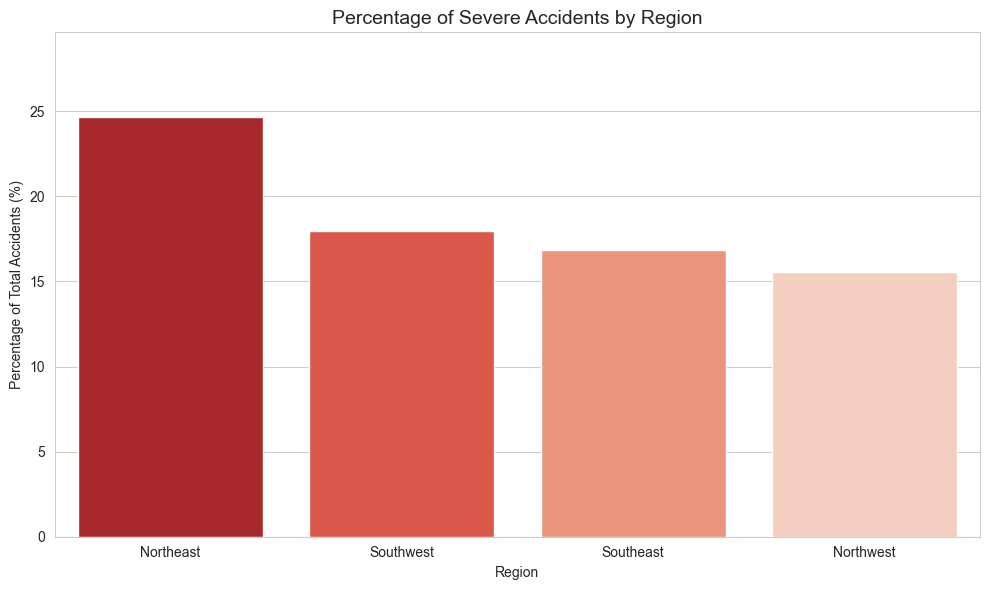

In [ ]:
# Calculating the % of Severe (3-4) vs Minor (1-2) accidents per region

# Define severity categories
df_prop = df.withColumn("Severity_Type", 
    when(col("Severity") >= 3, "Severe")
    .otherwise("Minor")
)
# Pivot the data to get percentages for a table
regional_pivot = df_prop.groupBy("Region").pivot("Severity_Type").count()
regional_pivot = regional_pivot.withColumn(
    "Severe_Percentage", 
    (col("Severe") / (col("Severe") + col("Minor"))) * 100
).orderBy("Severe_Percentage", ascending=False)

regional_pivot.show()
# Pivot and calculate percentages
severity_pivot = df_prop.groupBy("Region").pivot("Severity_Type").count()
severity_pivot = severity_pivot.withColumn(
    "Severe_Percentage", 
    round((col("Severe") / (col("Severe") + col("Minor"))) * 100, 2)
).orderBy("Severe_Percentage", ascending=False)

# Convert to Pandas for visualization
severity_pd = severity_pivot.toPandas()

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x="Region", y="Severe_Percentage", data=severity_pd, hue="Region", palette="Reds_r", legend=False)
plt.title("Percentage of Severe Accidents by Region", fontsize=14)
plt.ylabel("Percentage of Total Accidents (%)")
plt.xlabel("Region")
plt.ylim(0, max(severity_pd["Severe_Percentage"]) + 5)
plt.tight_layout()

plt.show()

--- Average Severity Score by Region ---
      Region  Avg_Severity
0  Northeast         2.285
1  Southwest         2.184
2  Northwest         2.183
3  Southeast         2.181
----------------------------------------


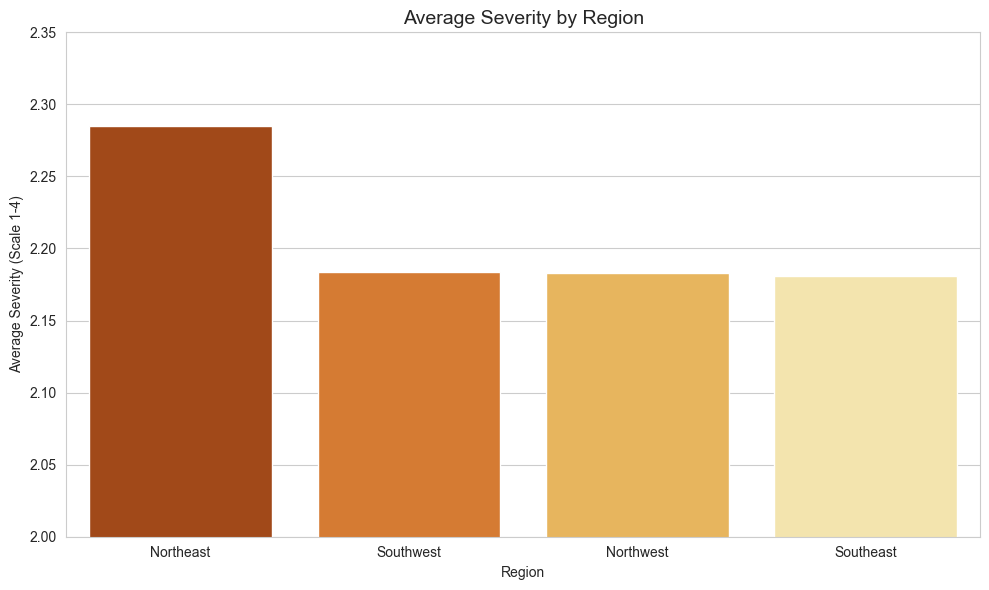

In [ ]:
# Calculate the average severity per region with Spark's 'avg' function to find the arithmetic mean
avg_severity_region = df.groupBy("Region") \
    .agg(round(avg("Severity"), 3).alias("Avg_Severity")) \
    .orderBy("Avg_Severity", ascending=False)

# Convert to Pandas for plotting
avg_severity_pd = avg_severity_region.toPandas()

# Print the numeric values for the report
print("--- Average Severity Score by Region ---")
print(avg_severity_pd)
print("-" * 40)

# Visualization
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plotting the Average Severity
ax = sns.barplot(x="Region", y="Avg_Severity", data=avg_severity_pd, hue="Region", palette="YlOrBr_r", legend=False)

plt.title("Average Severity by Region", fontsize=14)
plt.ylabel("Average Severity (Scale 1-4)")
plt.xlabel("Region")

# Adjusting y-axis
plt.ylim(2.0, 2.35) 

plt.tight_layout()
plt.show()

##### Weather Condition's effect on severity.
Analyzing it by plotting a heatmap with weather conditions and their severity within each region.

In [ ]:
# Calculating the percentage of 'Unknown' weather reports per region to assess data reliability.

weather_quality = df.groupBy("Region", "Weather_Group") \
    .count()

# Pivot to see Unknown vs Known easily
quality_pivot = weather_quality.groupBy("Region").pivot("Weather_Group").sum("count").fillna(0)

# Identify all columns that are NOT the 'Region' column
cols_to_sum = [col(c) for c in quality_pivot.columns if c != 'Region']

# Calculate % Unknown
# Formula: (Unknown / Total) * 100
quality_pivot = quality_pivot.withColumn("Total", reduce(lambda x, y: x + y, cols_to_sum)) \
                             .withColumn("Percent_Unknown", round((col("Unknown") / col("Total")) * 100, 2)) \
                             .select("Region", "Total", "Unknown", "Percent_Unknown") \
                             .orderBy("Percent_Unknown", ascending=False)

quality_pivot.show()

+---------+-------+-------+---------------+
|   Region|  Total|Unknown|Percent_Unknown|
+---------+-------+-------+---------------+
|Northeast|2241167|  71104|           3.17|
|Southwest|2819472|  69449|           2.46|
|Northwest| 364156|   7154|           1.96|
|Southeast|2303599|  29004|           1.26|
+---------+-------+-------+---------------+



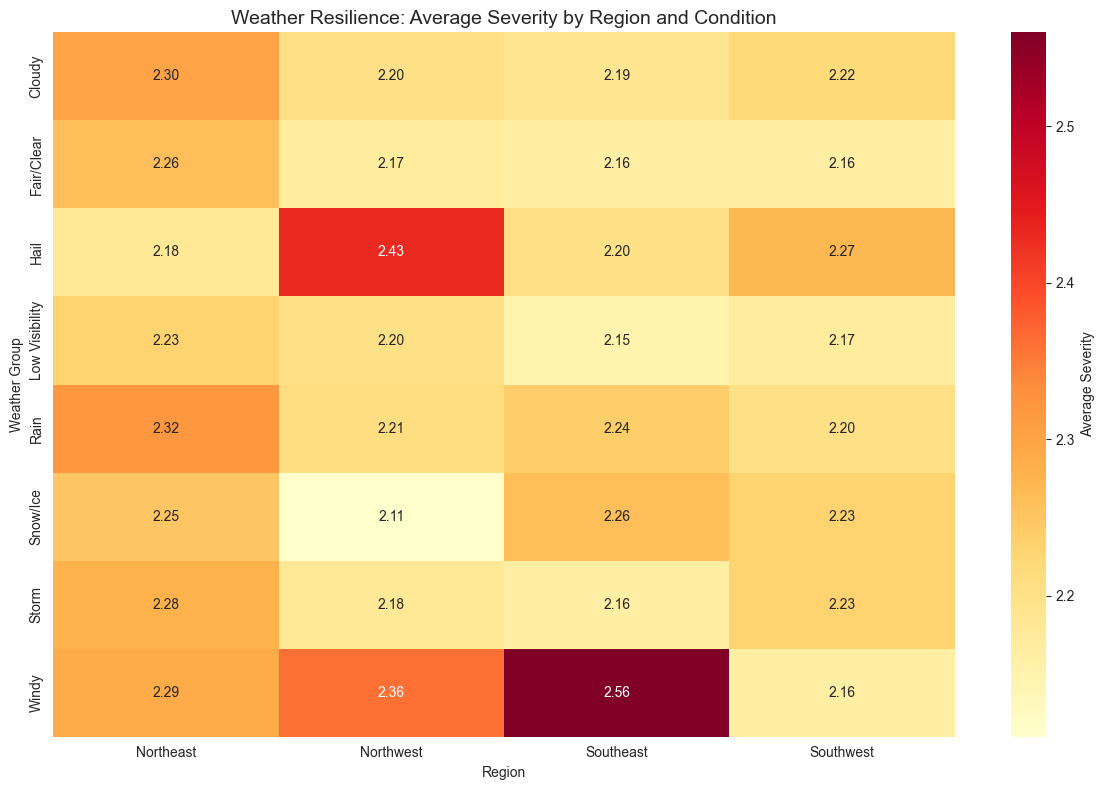

In [ ]:
# Aggregate average severity by Region and Weather Group
weather_resilience = df.groupBy("Region", "Weather_Group") \
    .agg(round(avg("Severity"), 2).alias("Avg_Severity")) \
    .filter(col("Weather_Group") != "Unknown")

# Pivot for Heatmap
weather_resilience_pd = weather_resilience.toPandas()
weather_pivot = weather_resilience_pd.pivot(index="Weather_Group", columns="Region", values="Avg_Severity")

# Visualization: Heatmap
plt.figure(figsize=(12, 8))
# Note: Using cbar_kws to correctly set the colorbar label
sns.heatmap(weather_pivot, 
            annot=True, 
            cmap="YlOrRd", 
            fmt=".2f", 
            cbar_kws={'label': 'Average Severity'})

plt.title("Weather Resilience: Average Severity by Region and Condition", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Weather Group")
plt.tight_layout()
plt.show()

### Regional Infrastructure Analysis

Analyzing five points of interest, which are: Bump, Crossing, Junction, Railway, and Traffic_Signal.

Beginning by calculating the involvement rate to determine what percentage of a region's total accidents actually occur at those locations by: $$ InvolvementRate = (\frac{FeatureCount}{Regiontotal})*100 %)$$

In [ ]:

# Define the infrastructure columns
infra_cols = ["Bump", "Crossing", "Junction", "Railway", "Traffic_Signal"]

# Reference the regional totals calculated earlier
region_totals = df.groupBy("Region").count().withColumnRenamed("count", "Region_Total")

# Run the main spark analysis
infra_stats_list = []

# Iterate through features to collect subset statistics
for feature in infra_cols:
    # Filter for records where the feature is present (True)
    feature_stats = df.filter(col(feature) == True) \
        .groupBy("Region") \
        .agg(
            count("*").alias("Feature_Count"),
            round(avg("Severity"), 3).alias("Avg_Severity")
        ) \
        .withColumn("Infrastructure_Type", lit(feature))
    
    infra_stats_list.append(feature_stats)

# Combine results and calculate percentages
infra_master_df = reduce(lambda df1, df2: df1.union(df2), infra_stats_list)

# Join with regional totals to calculate the normalized involvement percentage
infra_master_df = reduce(lambda df1, df2: df1.union(df2), infra_stats_list)
infra_final_df = infra_master_df.join(region_totals, "Region")
infra_final_df = infra_final_df.withColumn(
    "Involvement_Rate_Percent", 
    round((col("Feature_Count") / col("Region_Total")) * 100, 2)
)

# 4. CONVERT TO PANDAS (One master table for all visuals)
infra_master_pd = infra_final_df.toPandas()

# --- Visual 1: The Data Table ---
print("--- Infrastructure Regional Analysis Summary ---")
print(infra_master_pd[['Region', 'Infrastructure_Type', 'Involvement_Rate_Percent', 'Avg_Severity']].sort_values(['Infrastructure_Type', 'Region']))


--- Infrastructure Regional Analysis Summary ---
       Region Infrastructure_Type  Involvement_Rate_Percent  Avg_Severity
3   Northeast                Bump                      0.02         2.226
0   Northwest                Bump                      0.09         2.150
1   Southeast                Bump                      0.02         2.007
2   Southwest                Bump                      0.08         2.086
7   Northeast            Crossing                      9.28         2.162
4   Northwest            Crossing                     13.08         2.076
5   Southeast            Crossing                     14.63         2.021
6   Southwest            Crossing                      9.97         2.043
11  Northeast            Junction                      8.78         2.338
8   Northwest            Junction                      4.88         2.236
9   Southeast            Junction                      5.03         2.342
10  Southwest            Junction                      8.54    

##### Visualizing results
Heatmap of Infrastructure Involvement, and bar chart for impact of accidents near the same points of interests.

--- Infrastructure Regional Analysis Summary ---


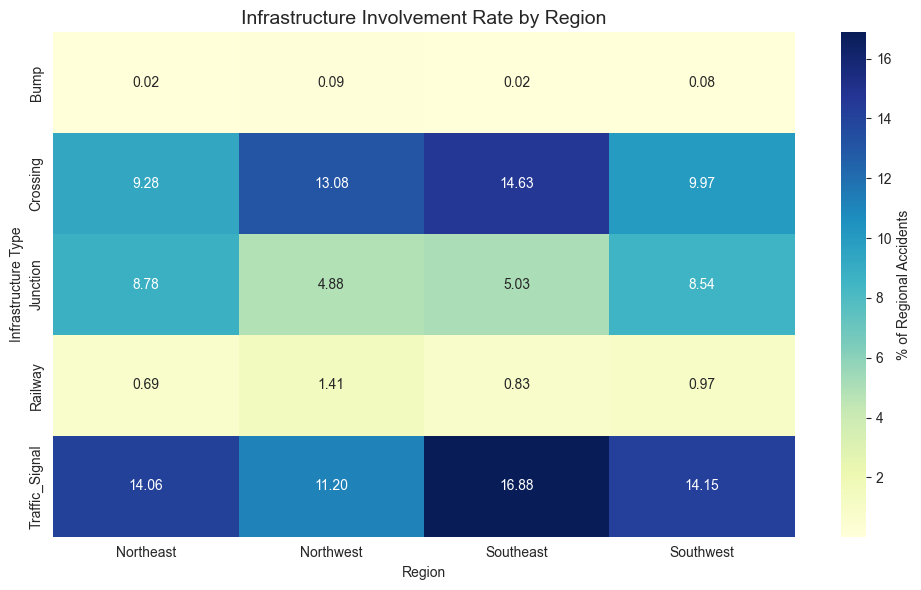

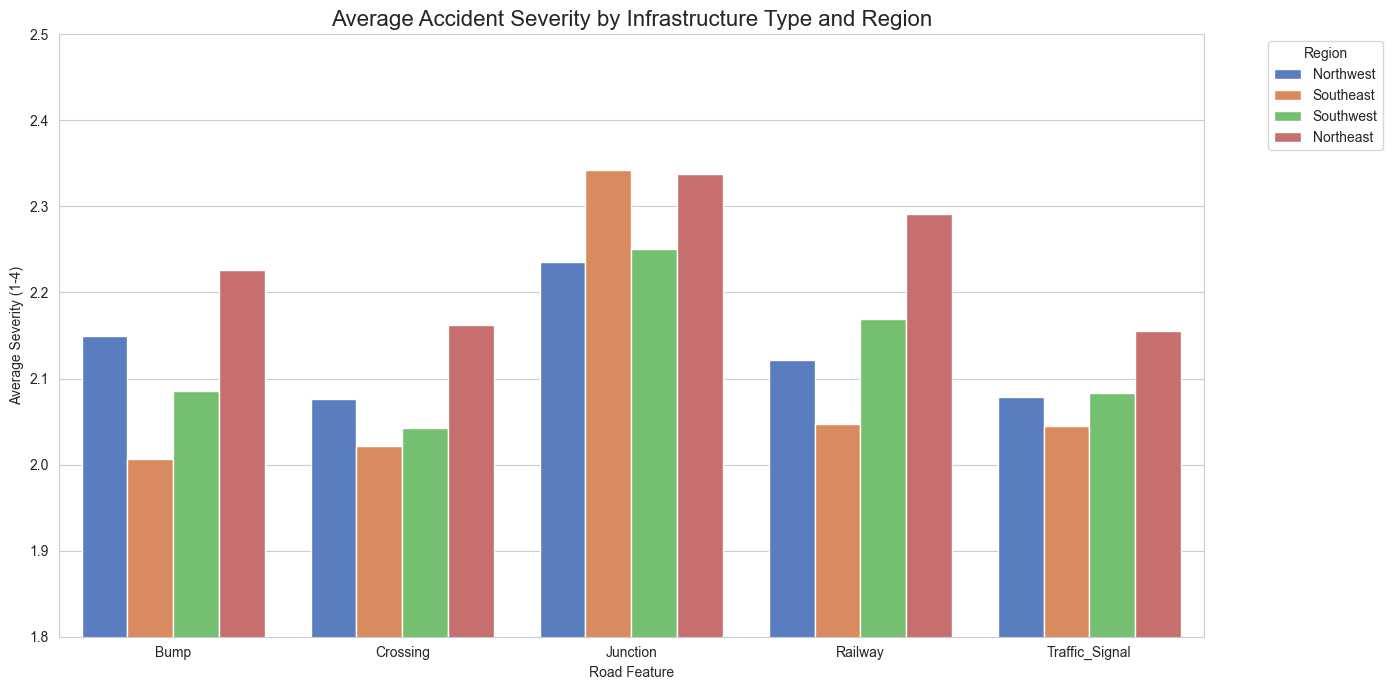

In [ ]:
print("--- Infrastructure Regional Analysis Summary ---")

# Heatmap of Involvement (%)
# We just pivot the data we already have in RAM
pivot_dist = infra_master_pd.pivot(index="Infrastructure_Type", columns="Region", values="Involvement_Rate_Percent")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_dist, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': '% of Regional Accidents'})
plt.title("Infrastructure Involvement Rate by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Infrastructure Type")
plt.tight_layout()
plt.show()

# Severity Bar Chart
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

ax = sns.barplot(x="Infrastructure_Type", y="Avg_Severity", hue="Region", data=infra_master_pd, palette="muted")
plt.title("Average Accident Severity by Infrastructure Type and Region", fontsize=16)
plt.ylabel("Average Severity (1-4)")
plt.xlabel("Road Feature")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(1.8, 2.5) 
plt.tight_layout()
plt.show()

#### Saving the Summaries to MongoDB 

In [ ]:
# Saving the 3 main summary tables to MongoDB
final_summary_tables = {
    "results_weather_summary": weather_resilience_pd,
    "results_regional_severity": severity_pd,
    "results_infrastructure_summary": infra_master_pd
}

print("--- Starting the save process to MongoDB ---")

for table_name, data_table in final_summary_tables.items():
    try:
        # Delete the old version in the database so we have a fresh start
        db[table_name].drop()
        
        # Turn the table into a list of rows and save them
        rows_to_save = data_table.to_dict("records")
        
        if rows_to_save:
            db[table_name].insert_many(rows_to_save)
            print(f"OK: Saved {table_name} ({len(rows_to_save)} rows)")
        else:
            print(f"Empty: {table_name} had no data to save.")
            
    except Exception as error:
        print(f"Error saving {table_name}: {error}")

print("-" * 50)
print("Summaries have been saved to MongoDB.")

--- Starting the save process to MongoDB ---
OK: Saved results_weather_summary (32 rows)
OK: Saved results_regional_severity (4 rows)
OK: Saved results_infrastructure_summary (20 rows)
--------------------------------------------------
Summaries have been saved to MongoDB.


# JARMON ANALYYSI

### Count of accident by severity avg %&/#¤%&/¤%#&#¤%&#¤&"#¤!%#&/¤&"#¤%

In [ ]:
df.groupBy("Weather_Group") \
    .agg(count("*").alias("accidents"),
         round(avg("Severity"), 2).alias("avg_severity")) \
    .orderBy("accidents", ascending=False) \
    .show()


+--------------+---------+------------+
| Weather_Group|accidents|avg_severity|
+--------------+---------+------------+
|    Fair/Clear|  3405216|        2.18|
|        Cloudy|  3163750|        2.23|
|          Rain|   540375|        2.25|
|Low Visibility|   203168|        2.18|
|       Unknown|   176711|        2.25|
|      Snow/Ice|   173727|        2.23|
|         Storm|    65248|        2.19|
|          Hail|      117|        2.25|
|         Windy|       82|        2.27|
+--------------+---------+------------+



### Check severity count

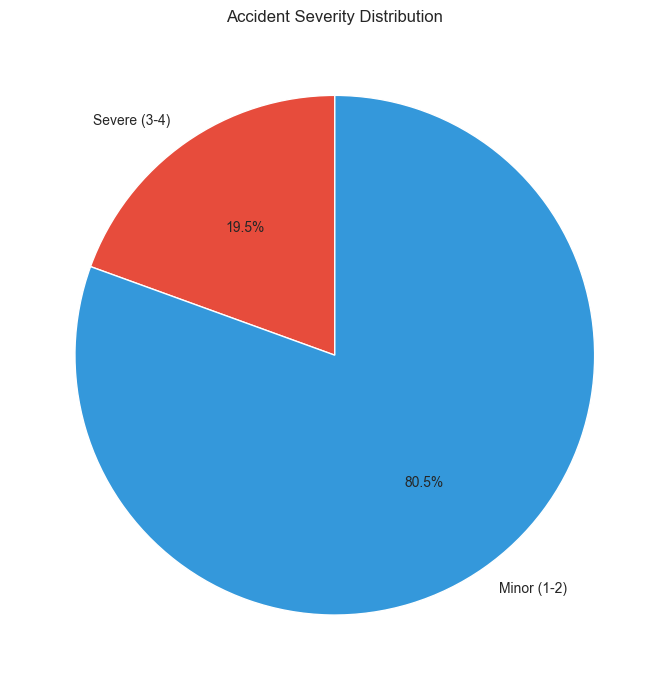

In [ ]:
severe = df.filter(df["Severity"] >= 3).count()
minor = df.filter(df["Severity"] < 3).count()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    [severe, minor],
    labels=["Severe (3-4)", "Minor (1-2)"],
    autopct="%1.1f%%",
    colors=["#e74c3c", "#3498db"],
    startangle=90
)
ax.set_title("Accident Severity Distribution")
plt.tight_layout()
plt.show()

### Näkyvyys onnettomuushetkellä

In [ ]:
df.createOrReplaceTempView("weather_accidents")
spark.sql("""
    SELECT 
        CASE 
            WHEN `Visibility(mi)` < 1 THEN 'Under 1 mile'
            WHEN `Visibility(mi)` < 5 THEN '1-5 miles'
            ELSE 'Over 5 miles'
        END as visibility,
        COUNT(*) as accidents,
        ROUND(AVG(Severity), 2) as avg_severity
    FROM weather_accidents
    GROUP BY visibility
    ORDER BY avg_severity DESC
""").show()

+------------+---------+------------+
|  visibility|accidents|avg_severity|
+------------+---------+------------+
|   1-5 miles|   506793|        2.23|
|Under 1 mile|   117131|        2.21|
|Over 5 miles|  7104470|        2.21|
+------------+---------+------------+



### Lämpötila onnettomuushetkellä

In [ ]:
spark.sql("""
    SELECT 
        CASE 
            WHEN `Temperature(F)` < 32 THEN 'Freezing (below 32F)'
            WHEN `Temperature(F)` < 60 THEN 'Cool (32-60F)'
            ELSE 'Warm (above 60F)'
        END as temperature,
        COUNT(*) as accidents,
        ROUND(AVG(Severity), 2) as avg_severity
    FROM weather_accidents
    GROUP BY temperature
    ORDER BY accidents DESC
""").show()

+--------------------+---------+------------+
|         temperature|accidents|avg_severity|
+--------------------+---------+------------+
|    Warm (above 60F)|  4549070|        2.21|
|       Cool (32-60F)|  2636084|        2.21|
|Freezing (below 32F)|   543240|        2.24|
+--------------------+---------+------------+



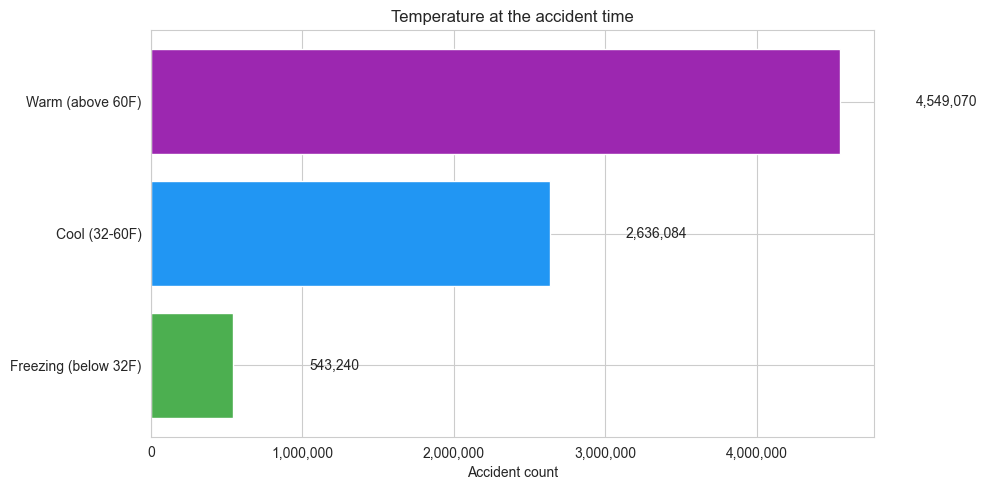

In [ ]:
data = {
    "temperature": ["Warm (above 60F)", "Cool (32-60F)", "Freezing (below 32F)"],
    "accidents": [4549070, 2636084, 543240]
}

temp_df = pd.DataFrame(data)
temp_df = temp_df.sort_values("accidents")

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(temp_df["temperature"], temp_df["accidents"], color=["#4CAF50", "#2196F3", "#9C27B0"])

for bar in bars:
    width = bar.get_width()
    ax.text(width + 500000, bar.get_y() + bar.get_height() / 2,
            f"{width:,}", va="center", fontsize=10)

ax.set_xlabel("Accident count")
ax.set_title("Temperature at the accident time")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

### Ristianalyysi lämmön ja sääolosuhgteen mukaan

In [ ]:
cross_analysis_pd = spark.sql("""
    SELECT
        Weather_Group,
        CASE
            WHEN `Temperature(F)` < 32 THEN 'Freezing'
            WHEN `Temperature(F)` < 60 THEN 'Cool'
            ELSE 'Warm'
        END as temperature,
        COUNT(*) as accidents,
        ROUND(AVG(Severity), 2) as avg_severity
    FROM weather_accidents
    WHERE Weather_Group IN ('Cloudy', 'Low Visibility', 'Unknown', 'Snow/Ice', 'Storm', 'Hail', 'Windy', 'Rain', 'Fair/Clear')
    GROUP BY Weather_Group, temperature
    ORDER BY accidents DESC
""").toPandas()

print(cross_analysis_pd)

     Weather_Group temperature  accidents  avg_severity
0       Fair/Clear        Warm    2126283          2.18
1           Cloudy        Warm    1885251          2.23
2           Cloudy        Cool    1086697          2.23
3       Fair/Clear        Cool    1085046          2.18
4             Rain        Cool     306031          2.25
5             Rain        Warm     229804          2.26
6       Fair/Clear    Freezing     193887          2.23
7           Cloudy    Freezing     191802          2.26
8          Unknown        Warm     155594          2.24
9         Snow/Ice    Freezing     131134          2.24
10  Low Visibility        Cool      96666          2.16
11  Low Visibility        Warm      90614          2.21
12           Storm        Warm      61011          2.19
13        Snow/Ice        Cool      42143          2.22
14  Low Visibility    Freezing      15888          2.18
15         Unknown        Cool      15224          2.34
16         Unknown    Freezing       5893       

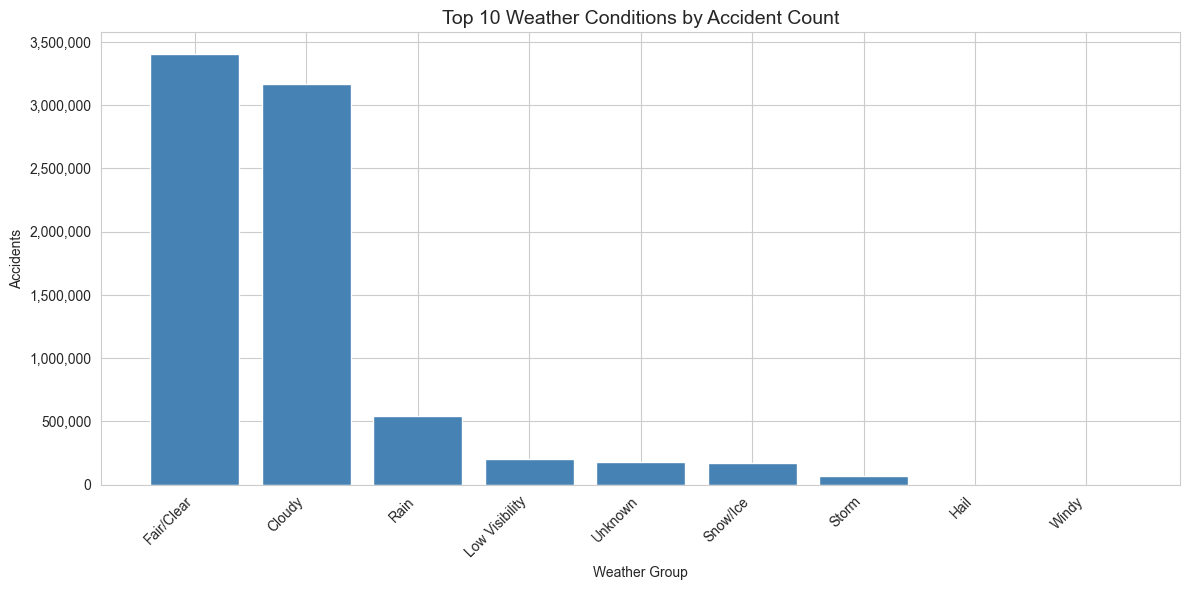

In [ ]:
weather_pd = df.groupBy("Weather_Group") \
    .agg(count("*").alias("accidents"),
         round(avg("Severity"), 2).alias("avg_severity")) \
    .orderBy("accidents", ascending=False) \
    .limit(10) \
    .toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(weather_pd["Weather_Group"], 
              weather_pd["accidents"],
              color="steelblue")
ax.set_title("Top 10 Weather Conditions by Accident Count", fontsize=14)
ax.set_xlabel("Weather Group")
ax.set_ylabel("Accidents")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

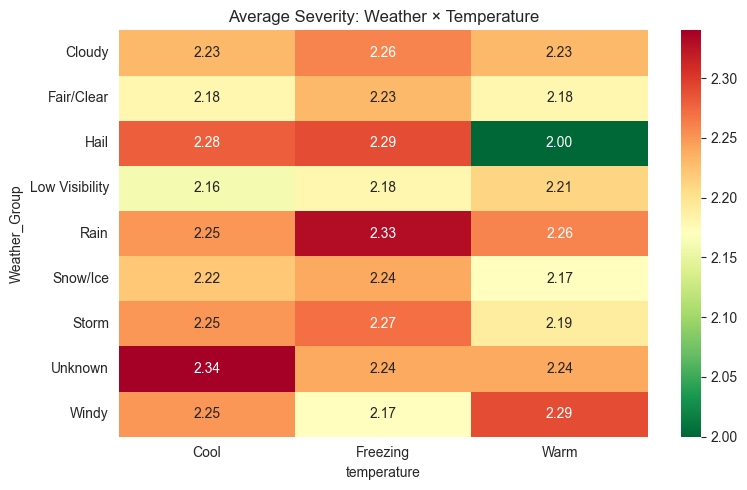

In [ ]:
pivot = cross_analysis_pd.pivot(index="Weather_Group",
                                columns="temperature",
                                values="avg_severity")


fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=ax)
ax.set_title("Average Severity: Weather × Temperature")
plt.tight_layout()
plt.show()

# EMMIN ANALYYSI

+----+------+
|hour| count|
+----+------+
|   0|112378|
|   1| 97071|
|   2| 93227|
|   3| 83707|
|   4|160008|
|   5|228182|
|   6|405837|
|   7|587472|
|   8|577576|
|   9|363034|
|  10|342706|
|  11|355040|
|  12|355001|
|  13|396445|
|  14|448846|
|  15|525855|
|  16|581969|
|  17|576015|
|  18|432042|
|  19|295121|
|  20|225226|
|  21|191452|
|  22|167645|
|  23|126539|
+----+------+



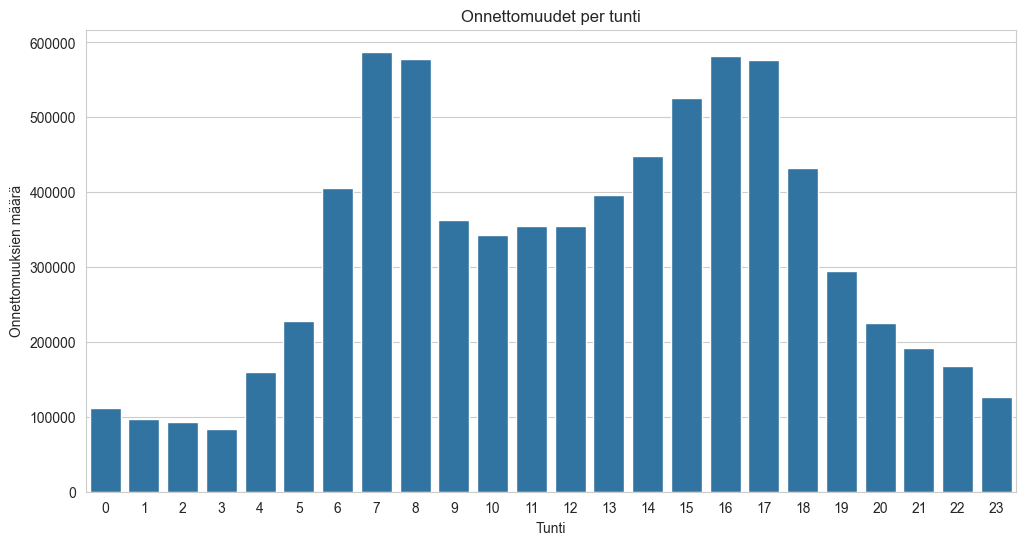

In [ ]:
from pyspark.sql.functions import to_timestamp, hour
df = spark.read.csv("US_Accidents_March23.csv", header=True, inferSchema=True)

df = df.withColumn("Start_Time", to_timestamp("Start_Time"))
df = df.withColumn("hour", hour("Start_Time"))
acc_per_hour = df.groupBy("hour").count().orderBy("hour")
acc_per_hour.show(24)
pdf = acc_per_hour.toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=pdf, x="hour", y="count")
plt.title("Onnettomuudet per tunti")
plt.xlabel("Tunti")
plt.ylabel("Onnettomuuksien määrä")
plt.show()


In [ ]:
#Top 5 the most dangerous hours when accidents occurs
from pyspark.sql.functions import col
 
top5_hours = acc_per_hour.orderBy(col("count").desc()).limit(5)
 
print("Top 5 hours - the most dangerous hours:")
top5_hours.show()
 

Top 5 hours - the most dangerous hours:
+----+------+
|hour| count|
+----+------+
|   7|587472|
|  16|581969|
|   8|577576|
|  17|576015|
|  15|525855|
+----+------+



# EMMAN ANALYYSI

### Convert to Spark and create traffic period features

In [ ]:

df = df.withColumn("hour", hour(col("Start_Time")))

df = df.withColumn(
    "Traffic_Period",
    when((col("hour") >= 6) & (col("hour") < 10), "Morning Rush")
    .when((col("hour") >= 15) & (col("hour") < 19), "Afternoon Rush")
    .when((col("hour") >= 10) & (col("hour") < 15), "Midday")
    .otherwise("Late evening/night")
)

### Analyse the rush-hour effect

In [ ]:
print("Accidents by traffic period category:")
df.groupBy("Traffic_Period").agg(
    count("*").alias("accident_count"),
    round(avg("Severity"), 2).alias("avg_severity")
).orderBy("accident_count", ascending=False).show()

print("Accidents by hour:")
df.groupBy("hour").agg(
    count("*").alias("accident_count"),
    round(avg("Severity"), 2).alias("avg_severity")
).orderBy("hour").show()

Accidents by traffic period category:
+------------------+--------------+------------+
|    Traffic_Period|accident_count|avg_severity|
+------------------+--------------+------------+
|    Afternoon Rush|       2115881|        2.21|
|      Morning Rush|       1933919|         2.2|
|            Midday|       1898038|        2.21|
|Late evening/night|       1780556|        2.23|
+------------------+--------------+------------+

Accidents by hour:
+----+--------------+------------+
|hour|accident_count|avg_severity|
+----+--------------+------------+
|   0|        112378|        2.22|
|   1|         97071|        2.19|
|   2|         93227|        2.21|
|   3|         83707|        2.23|
|   4|        160008|        2.23|
|   5|        228182|        2.22|
|   6|        405837|        2.21|
|   7|        587472|        2.19|
|   8|        577576|        2.19|
|   9|        363034|        2.23|
|  10|        342706|        2.22|
|  11|        355040|        2.21|
|  12|        355001|    

### Testing Spark SQL's functionality

In [ ]:
df.createOrReplaceTempView("accidents")

spark.sql("""
SELECT hour, COUNT(*) AS accident_count, AVG(Severity) AS avg_severity
FROM accidents
GROUP BY hour
ORDER BY hour
""").show(24)

+----+--------------+------------------+
|hour|accident_count|      avg_severity|
+----+--------------+------------------+
|   0|        112378|2.2188239691042733|
|   1|         97071|2.1888720627169804|
|   2|         93227|2.2057772962768296|
|   3|         83707| 2.229431230363052|
|   4|        160008|2.2340195490225487|
|   5|        228182| 2.219298630040932|
|   6|        405837|2.2091282953501037|
|   7|        587472| 2.190158850123921|
|   8|        577576| 2.191276992118786|
|   9|        363034|2.2259044607392147|
|  10|        342706|2.2201187023279427|
|  11|        355040|2.2142012167643084|
|  12|        355001|2.2163289680874136|
|  13|        396445| 2.207443655488151|
|  14|        448846| 2.199885929695263|
|  15|        525855|2.2014338553403503|
|  16|        581969| 2.205476580367683|
|  17|        576015| 2.210293134727394|
|  18|        432042| 2.227924599923156|
|  19|        295121|2.2371061361272155|
|  20|        225226|2.2474803086677384|
|  21|        19

In [ ]:
spark.sql("""
SELECT 
    Traffic_Period,
    COUNT(*) AS accident_count,
    ROUND(AVG(Severity), 2) AS avg_severity
FROM accidents
GROUP BY Traffic_Period
""").show()

+------------------+--------------+------------+
|    Traffic_Period|accident_count|avg_severity|
+------------------+--------------+------------+
|    Afternoon Rush|       2115881|        2.21|
|            Midday|       1898038|        2.21|
|Late evening/night|       1780556|        2.23|
|      Morning Rush|       1933919|         2.2|
+------------------+--------------+------------+



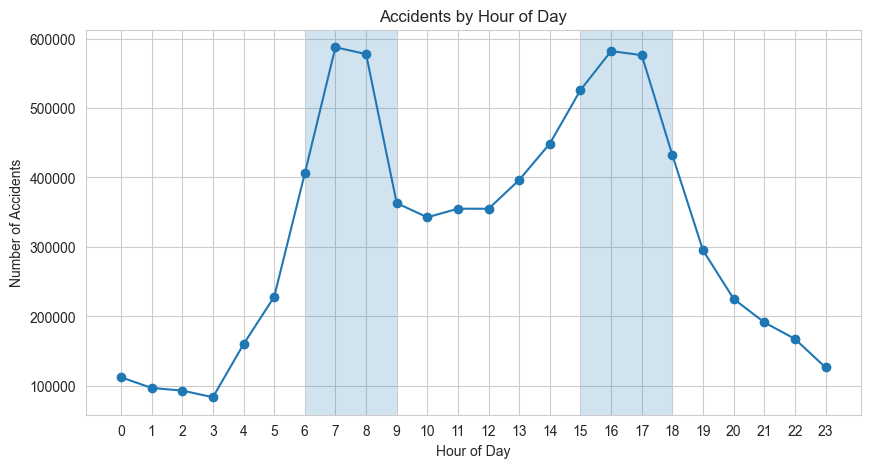

In [ ]:
import matplotlib.pyplot as plt

hourly_pd = df.groupBy("hour").agg(
    count("*").alias("accident_count")
).orderBy("hour").toPandas()

plt.figure(figsize=(10, 5))
plt.plot(hourly_pd["hour"], hourly_pd["accident_count"], marker="o")
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.xticks(range(24))
plt.axvspan(6, 9, alpha=0.2) 
plt.axvspan(15, 18, alpha=0.2)
plt.show()

### What this graph tells us?

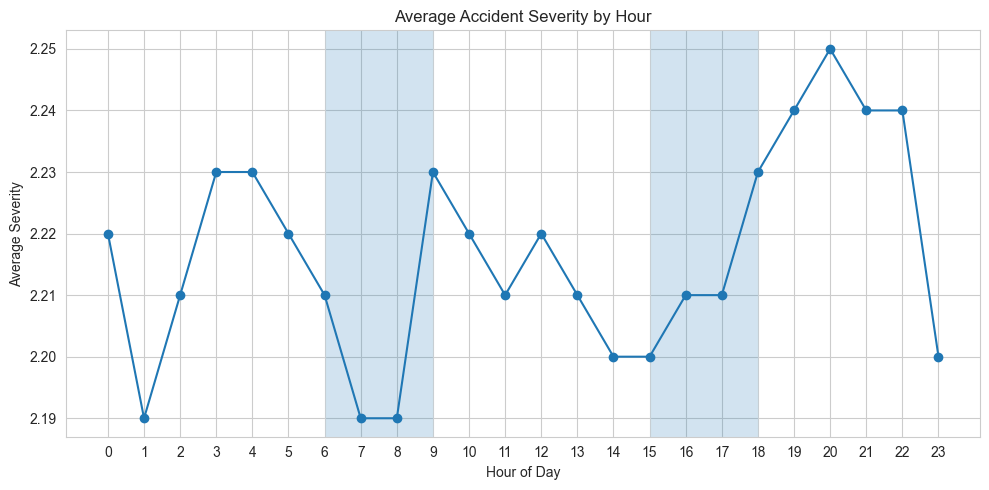

In [ ]:
hourly_pd = df.groupBy("hour").agg(
    round(avg("Severity"), 2).alias("avg_severity")
).orderBy("hour").toPandas()

plt.figure(figsize=(10, 5))
plt.plot(hourly_pd["hour"], hourly_pd["avg_severity"], marker="o")
plt.title("Average Accident Severity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Severity")
plt.xticks(range(24))
plt.tight_layout()
plt.axvspan(6, 9, alpha=0.2) 
plt.axvspan(15, 18, alpha=0.2)
plt.show()

### What this graph tells us?
- Severity doesn't seem to correlate much with the rush-hours
- Interestingly the two highest peaks in severity are outside of rush-hours
- The most significant peaks are timed around 4:00 and 20:00 o'clock whereas less significant peaks are around midnight and around the last hour of morning rush